In [2]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

pd.set_option("display.float_format", "{:.4f}".format)
DATA_DIR = "../data"

In [3]:
#Load and build combined dataset
prices     = pd.read_csv(os.path.join(DATA_DIR, "spot_prices.csv"),  parse_dates=["HourDK"])
production = pd.read_csv(os.path.join(DATA_DIR, "production.csv"),   parse_dates=["HourDK"])

production["OffshoreWind"] = production["OffshoreWindLt100MW_MWh"] + production["OffshoreWindGe100MW_MWh"]
production["OnshoreWind"]  = production["OnshoreWindLt50kW_MWh"]   + production["OnshoreWindGe50kW_MWh"]
production["Solar"]        = (production["SolarPowerLt10kW_MWh"]
                              + production["SolarPowerGe10Lt40kW_MWh"]
                              + production["SolarPowerGe40kW_MWh"])

combined = pd.merge(
    prices[["HourDK", "SpotPriceEUR"]],
    production[["HourDK", "OffshoreWind", "OnshoreWind", "Solar", "GrossConsumptionMWh"]],
    on="HourDK",
    how="inner"
).sort_values("HourDK").reset_index(drop=True)

combined["TotalWind"] = combined["OffshoreWind"] + combined["OnshoreWind"]

print(f"Rows: {len(combined)}")
print(f"Range: {combined['HourDK'].min()} → {combined['HourDK'].max()}")
combined.head()

Rows: 2160
Range: 2025-07-02 00:00:00 → 2025-09-29 23:00:00


,HourDK,SpotPriceEUR,OffshoreWind,OnshoreWind,Solar,GrossConsumptionMWh,TotalWind
0,2025-07-02 00:00:00,119.2900,324.2819,335.6035,0.5340,2253.0520,659.8855
1,2025-07-02 01:00:00,102.7000,393.9523,340.6398,0.4309,2234.6694,734.5921
2,2025-07-02 02:00:00,92.5400,430.9745,386.2130,0.3986,2306.8370,817.1875
3,2025-07-02 03:00:00,92.0800,321.3976,423.6959,0.5746,2207.1964,745.0935
4,2025-07-02 04:00:00,91.7100,178.6053,309.7509,2.9238,2142.2299,488.3563


In [4]:
#Stationary test helper
def stationarity_report(series: pd.Series, name: str) -> dict:
    """
    Run ADF and KPSS tests on a series and print a plain-english summary.

    ADF  null hypothesis : series HAS a unit root (non-stationary)
         p < 0.05        → reject null → stationary
    KPSS null hypothesis : series IS stationary
         p < 0.05        → reject null → non-stationary

    We want ADF p < 0.05 AND KPSS p > 0.05 to confidently call a series stationary.
    """
    series = series.dropna()

    adf_stat, adf_p, _, _, adf_crit, _ = adfuller(series, autolag="AIC")
    kpss_stat, kpss_p, _, kpss_crit    = kpss(series, regression="c", nlags="auto")

    adf_conclusion  = "stationary"     if adf_p  < 0.05 else "non-stationary"
    kpss_conclusion = "non-stationary" if kpss_p < 0.05 else "stationary"

    if adf_conclusion == kpss_conclusion:
        verdict = f"✓ Both agree: {adf_conclusion}"
    else:
        verdict = "⚠ Tests disagree — likely trend-stationary or fractionally integrated"

    print(f"\n{'─'*50}")
    print(f"  {name}")
    print(f"{'─'*50}")
    print(f"  ADF  statistic: {adf_stat:.4f}  p-value: {adf_p:.4f}  → {adf_conclusion}")
    print(f"  KPSS statistic: {kpss_stat:.4f}  p-value: {kpss_p:.4f}  → {kpss_conclusion}")
    print(f"  Verdict: {verdict}")

    return {"series": name, "adf_p": adf_p, "kpss_p": kpss_p,
            "adf": adf_conclusion, "kpss": kpss_conclusion, "verdict": verdict}

In [5]:
# This tells us whether each series is stationary before we do anything else.
# Non-stationary series need differencing before correlation/causality analysis.

results = []
for col, label in [
    ("SpotPriceEUR",       "Spot Price (EUR/MWh)"),
    ("TotalWind",          "Total Wind Production (MWh)"),
    ("OffshoreWind",       "Offshore Wind (MWh)"),
    ("OnshoreWind",        "Onshore Wind (MWh)"),
    ("Solar",              "Solar Production (MWh)"),
    ("GrossConsumptionMWh","Gross Consumption (MWh)"),
]:
    results.append(stationarity_report(combined[col], label))

print("\n\nDone. See verdicts above before proceeding.")


──────────────────────────────────────────────────
  Spot Price (EUR/MWh)
──────────────────────────────────────────────────
  ADF  statistic: -5.3809  p-value: 0.0000  → stationary
  KPSS statistic: 0.2604  p-value: 0.1000  → stationary
  Verdict: ✓ Both agree: stationary

──────────────────────────────────────────────────
  Total Wind Production (MWh)
──────────────────────────────────────────────────
  ADF  statistic: -6.4969  p-value: 0.0000  → stationary
  KPSS statistic: 0.7615  p-value: 0.0100  → non-stationary
  Verdict: ⚠ Tests disagree — likely trend-stationary or fractionally integrated

──────────────────────────────────────────────────
  Offshore Wind (MWh)
──────────────────────────────────────────────────
  ADF  statistic: -6.8983  p-value: 0.0000  → stationary
  KPSS statistic: 0.9872  p-value: 0.0100  → non-stationary
  Verdict: ⚠ Tests disagree — likely trend-stationary or fractionally integrated

──────────────────────────────────────────────────
  Onshore Wind (MWh

/var/folders/rw/4wzf08v1417ghqx8fbxjblm80000gn/T/ipykernel_60362/3186953580.py:16: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, kpss_crit    = kpss(series, regression="c", nlags="auto")
/var/folders/rw/4wzf08v1417ghqx8fbxjblm80000gn/T/ipykernel_60362/3186953580.py:16: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, kpss_crit    = kpss(series, regression="c", nlags="auto")
/var/folders/rw/4wzf08v1417ghqx8fbxjblm80000gn/T/ipykernel_60362/3186953580.py:16: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, kpss_crit    = kpss(series, regression="c", nlags="auto")
/var

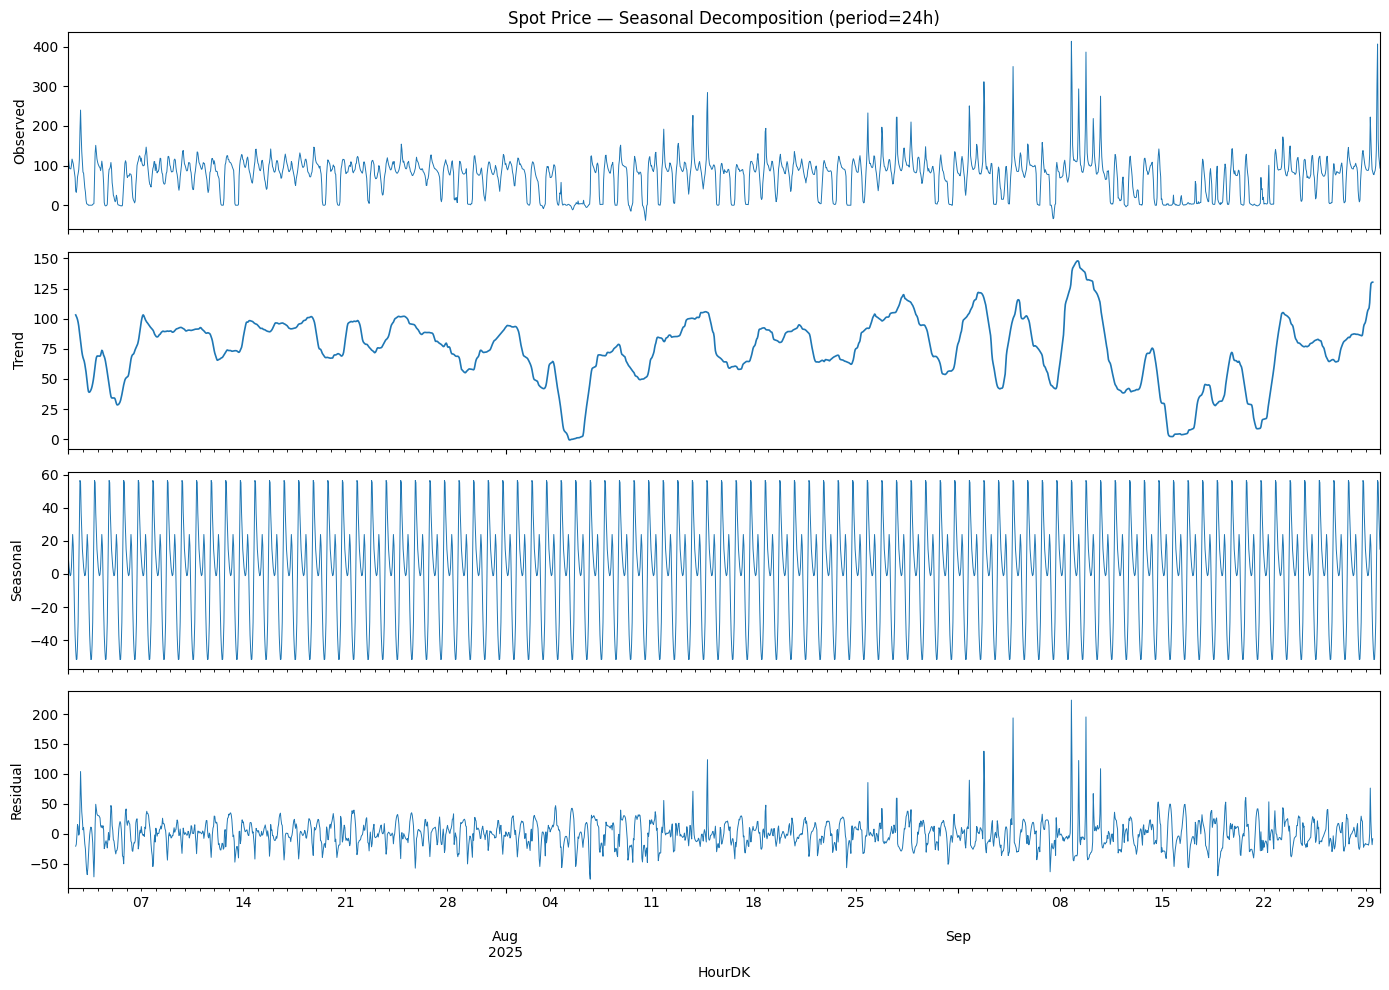

In [6]:
# Decompose into trend, seasonality, and residual.
# We use model="additive" — appropriate when seasonal variation is roughly constant.
# Period=24 captures the daily cycle (24 hourly observations per day).

decomp_price = seasonal_decompose(
    combined.set_index("HourDK")["SpotPriceEUR"],
    model="additive",
    period=24
)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomp_price.observed.plot(ax=axes[0], linewidth=0.7);  axes[0].set_ylabel("Observed")
decomp_price.trend.plot(ax=axes[1], linewidth=1.2);     axes[1].set_ylabel("Trend")
decomp_price.seasonal.plot(ax=axes[2], linewidth=0.7);  axes[2].set_ylabel("Seasonal")
decomp_price.resid.plot(ax=axes[3], linewidth=0.7);     axes[3].set_ylabel("Residual")
axes[0].set_title("Spot Price — Seasonal Decomposition (period=24h)")
plt.tight_layout()
plt.show()

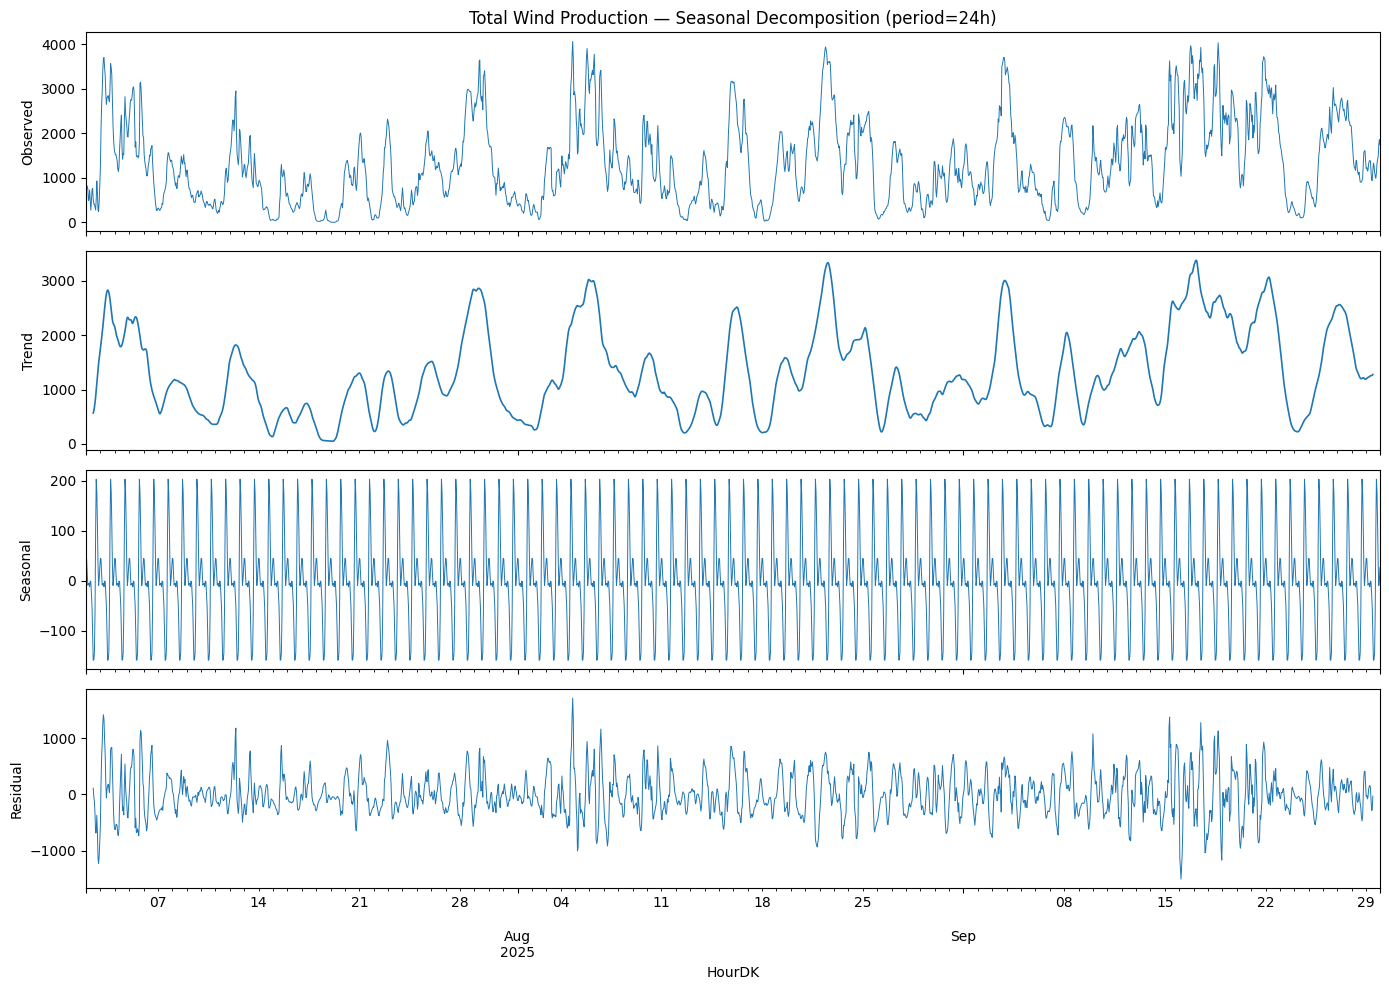

In [7]:
decomp_wind = seasonal_decompose(
    combined.set_index("HourDK")["TotalWind"],
    model="additive",
    period=24
)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomp_wind.observed.plot(ax=axes[0], linewidth=0.7);  axes[0].set_ylabel("Observed")
decomp_wind.trend.plot(ax=axes[1], linewidth=1.2);     axes[1].set_ylabel("Trend")
decomp_wind.seasonal.plot(ax=axes[2], linewidth=0.7);  axes[2].set_ylabel("Seasonal")
decomp_wind.resid.plot(ax=axes[3], linewidth=0.7);     axes[3].set_ylabel("Residual")
axes[0].set_title("Total Wind Production — Seasonal Decomposition (period=24h)")
plt.tight_layout()
plt.show()

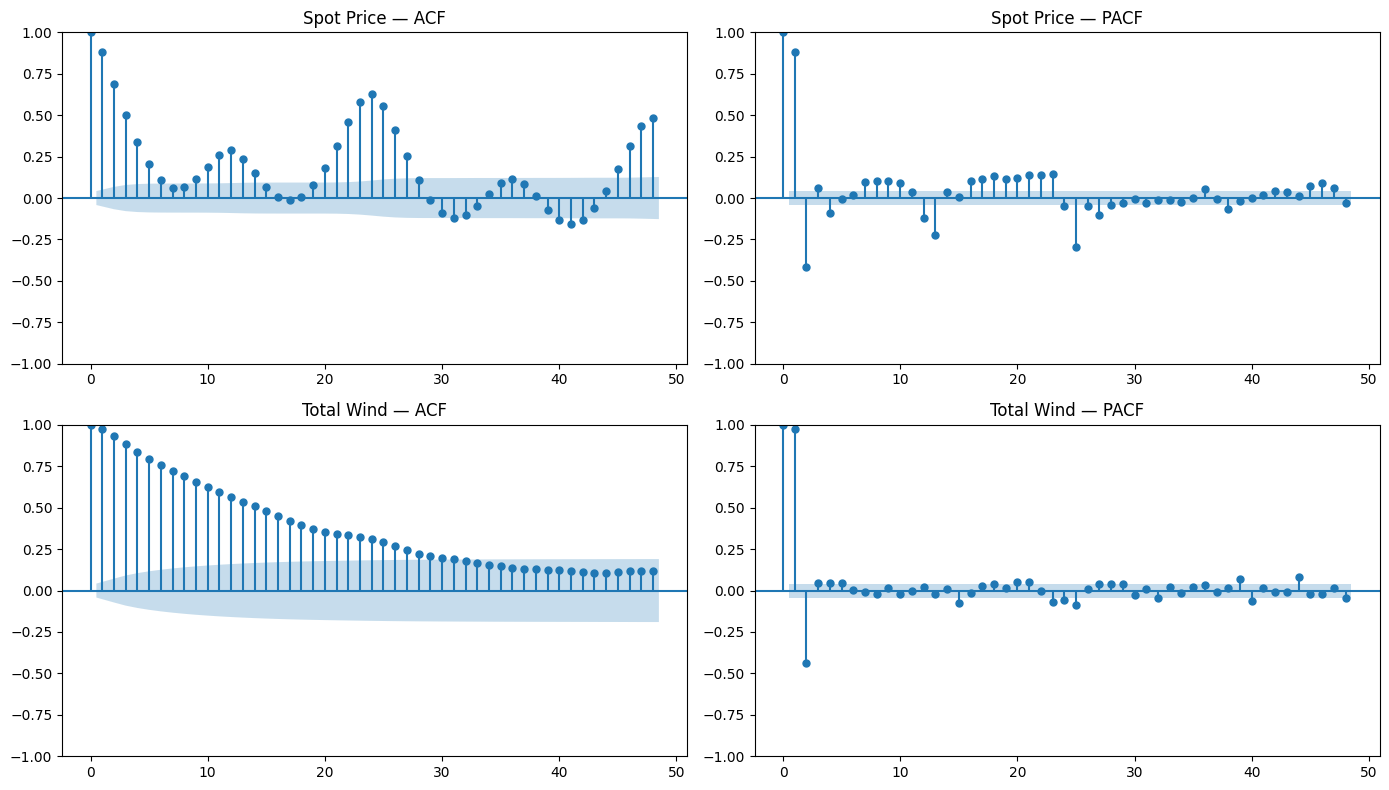

In [8]:
# ACF  = autocorrelation — how correlated is the series with its own past values?
# PACF = partial autocorrelation — same but removing the effect of intermediate lags
#
# What to look for:
#   ACF cuts off sharply  → MA process
#   PACF cuts off sharply → AR process
#   Both decay slowly     → non-stationary (confirms ADF/KPSS results)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf( combined["SpotPriceEUR"], lags=48, ax=axes[0][0], title="Spot Price — ACF")
plot_pacf(combined["SpotPriceEUR"], lags=48, ax=axes[0][1], title="Spot Price — PACF")
plot_acf( combined["TotalWind"],    lags=48, ax=axes[1][0], title="Total Wind — ACF")
plot_pacf(combined["TotalWind"],    lags=48, ax=axes[1][1], title="Total Wind — PACF")

plt.tight_layout()
plt.show()

In [9]:
# If stationarity tests above flagged non-stationary series,
# we difference them here. First differencing removes trends.
# ΔY_t = Y_t - Y_(t-1)
#
# We save differenced columns alongside originals so we can
# choose which to use in notebooks 03 and 04.

combined["SpotPriceEUR_diff"] = combined["SpotPriceEUR"].diff()
combined["TotalWind_diff"]    = combined["TotalWind"].diff()
combined["OffshoreWind_diff"] = combined["OffshoreWind"].diff()
combined["OnshoreWind_diff"]  = combined["OnshoreWind"].diff()
combined["Solar_diff"]        = combined["Solar"].diff()

# Drop the single NaN introduced by differencing
combined_diff = combined.dropna().reset_index(drop=True)

print("Differenced columns added:")
print([c for c in combined_diff.columns if c.endswith("_diff")])

Differenced columns added:
['SpotPriceEUR_diff', 'TotalWind_diff', 'OffshoreWind_diff', 'OnshoreWind_diff', 'Solar_diff']


In [10]:
# After differencing, these should now pass both tests.
# If they still don't, we may need second differencing (rare).

for col, label in [
    ("SpotPriceEUR_diff", "Spot Price — first difference"),
    ("TotalWind_diff",    "Total Wind — first difference"),
]:
    stationarity_report(combined_diff[col], label)


──────────────────────────────────────────────────
  Spot Price — first difference
──────────────────────────────────────────────────
  ADF  statistic: -10.3148  p-value: 0.0000  → stationary
  KPSS statistic: 0.0105  p-value: 0.1000  → stationary
  Verdict: ✓ Both agree: stationary

──────────────────────────────────────────────────
  Total Wind — first difference
──────────────────────────────────────────────────
  ADF  statistic: -10.8352  p-value: 0.0000  → stationary
  KPSS statistic: 0.0060  p-value: 0.1000  → stationary
  Verdict: ✓ Both agree: stationary


/var/folders/rw/4wzf08v1417ghqx8fbxjblm80000gn/T/ipykernel_60362/3186953580.py:16: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, kpss_crit    = kpss(series, regression="c", nlags="auto")
/var/folders/rw/4wzf08v1417ghqx8fbxjblm80000gn/T/ipykernel_60362/3186953580.py:16: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, kpss_crit    = kpss(series, regression="c", nlags="auto")


In [11]:
out_path = os.path.join(DATA_DIR, "combined.csv")
combined_diff.to_csv(out_path, index=False)
print(f"Saved → {out_path}")
print(f"Columns: {combined_diff.columns.tolist()}")

Saved → ../data/combined.csv
Columns: ['HourDK', 'SpotPriceEUR', 'OffshoreWind', 'OnshoreWind', 'Solar', 'GrossConsumptionMWh', 'TotalWind', 'SpotPriceEUR_diff', 'TotalWind_diff', 'OffshoreWind_diff', 'OnshoreWind_diff', 'Solar_diff']
